In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from tqdm.auto import tqdm

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / "benchmarks").exists():
    repo_root = repo_root.parent
if not (repo_root / "benchmarks").exists():
    raise RuntimeError("Could not locate repo root containing 'benchmarks'.")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from benchmarks._utils import build_dataset, build_model, build_network
from genkit.metrics import fid, metric_on_quantile, mssle, wasserstein_distance

plt.rcParams.update({"figure.dpi": 120})


/home/hcherkaoui/src/flowbench/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
exploit_dir = repo_root / "benchmarks" / "_exploit"
heavy_flow_dir = sorted(exploit_dir.glob("*_heavy_flow"))[-1]
alpha_map_dir = sorted(exploit_dir.glob("*_alpha_map"))[-1]

n_eval_samples = 4096
xi_metric = 0.99
device = "cpu"

In [3]:
def run_dirs(batch_dir: Path):
    return sorted(path for path in batch_dir.iterdir() if path.is_dir() and path.name[:3].isdigit())


def load_generator(run_dir: Path, *, device: str = "cpu"):
    checkpoint = torch.load(run_dir / "checkpoint.pt", map_location=device)
    config = yaml.safe_load((run_dir / "config.yaml").read_text())
    dtype_name = str(checkpoint["model_init"]["dtype"]).split(".")[-1]
    dtype = getattr(torch, dtype_name)
    network_cfg = yaml.safe_load(yaml.safe_dump(checkpoint["model_init"]["network"]))
    model_cfg = yaml.safe_load(yaml.safe_dump(checkpoint["model_init"]["model"]))
    model_cfg.setdefault("params", {})
    model_cfg["params"]["fdtype"] = dtype
    model_cfg["params"]["device"] = device

    x_train, _, x_test = build_dataset(config["dataset"], dtype=dtype, device=device)
    net, _ = build_network(network_cfg, x_train)
    net = net.to(device=device, dtype=dtype)
    generator, _ = build_model(model_cfg, net, x_train, dtype=dtype, device=device)
    generator._net.load_state_dict(checkpoint["network_state_dict"])
    generator._net.eval()
    return generator, x_test, config


def evaluate_run(run_dir: Path, *, n_samples: int, xi: float, device: str = "cpu") -> dict:
    generator, x_test, config = load_generator(run_dir, device=device)
    x_ref = x_test[: min(n_samples, len(x_test)), :]
    x_gen = generator.sample(n_samples=len(x_ref))
    return {
        "run_dir": run_dir.name,
        "dataset_name": config["dataset"]["name"],
        "dataset_alpha": config["dataset"]["params"].get("alpha"),
        "model_name": config["model"]["name"],
        "model_preset": config["model"].get("preset_name", config["model"]["name"]),
        "model_alpha": config["model"]["params"].get("alpha"),
        "FID": float(fid(x_ref, x_gen)),
        "W1": float(wasserstein_distance(x_ref, x_gen, p=1)),
        "MSSLE_99": float(metric_on_quantile(mssle, x_ref, x_gen, xi=xi, reduction="mean")),
    }


def metric_map(ax, df: pd.DataFrame, metric: str, title: str):
    pivot = df.pivot(index="dataset_alpha", columns="model_alpha", values=metric).sort_index().sort_index(axis=1)
    image = ax.imshow(pivot.values, origin="lower", aspect="auto")
    ax.set_title(title)
    ax.set_xlabel(r"$\alpha_{\mathrm{model}}$")
    ax.set_ylabel(r"$\alpha_{\mathrm{data}}$")
    ax.set_xticks(np.arange(len(pivot.columns)), [f"{alpha:.3g}" for alpha in pivot.columns])
    ax.set_yticks(np.arange(len(pivot.index)), [f"{alpha:.3g}" for alpha in pivot.index])
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.values[i, j]:.2g}", ha="center", va="center", color="white", fontsize=8)
    return image


In [4]:
heavy_rows = [
    evaluate_run(run_dir, n_samples=n_eval_samples, xi=xi_metric, device=device)
    for run_dir in tqdm(run_dirs(heavy_flow_dir), desc="Evaluating heavy-flow runs")
]
heavy_df = pd.DataFrame(heavy_rows).sort_values("model_preset").reset_index(drop=True)
display(heavy_df[["model_preset", "FID", "W1", "MSSLE_99"]].round(4))


Evaluating heavy-flow runs: 100%|██████████| 2/2 [00:17<00:00,  8.78s/it]


,model_preset,FID,W1,MSSLE_99
0,heavy_tail_linear__alpha-1p6,1014.2007,7.3534,0.4342
1,lipman_2022,3.9804,5.9390,0.0544


Evaluating alpha-map runs: 100%|██████████| 25/25 [02:05<00:00,  5.04s/it]


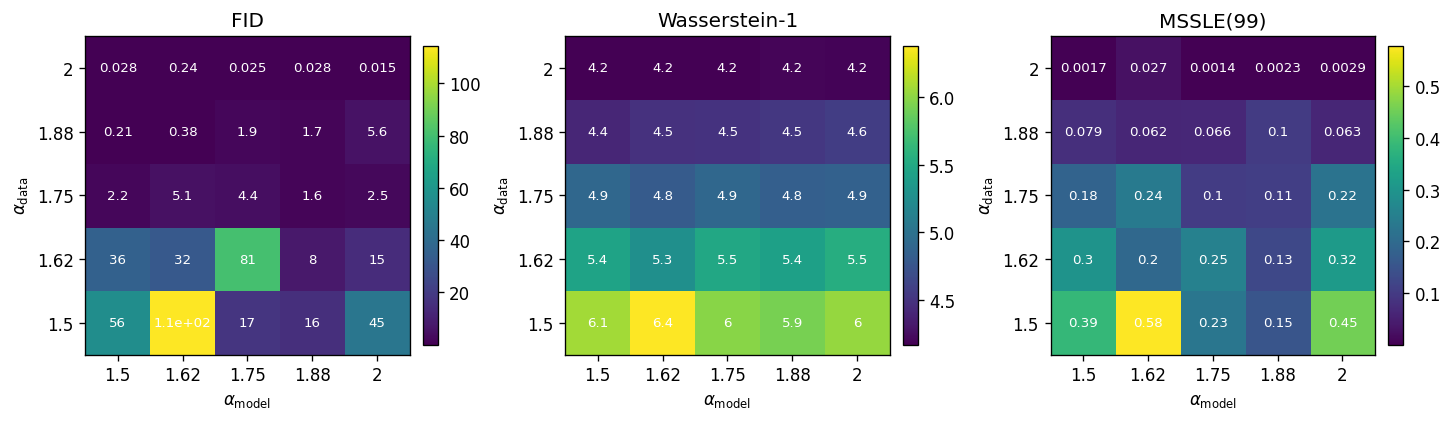

In [5]:
alpha_rows = [
    evaluate_run(run_dir, n_samples=n_eval_samples, xi=xi_metric, device=device)
    for run_dir in tqdm(run_dirs(alpha_map_dir), desc="Evaluating alpha-map runs")
]
alpha_df = pd.DataFrame(alpha_rows).sort_values(["dataset_alpha", "model_alpha"]).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.4), constrained_layout=True)
images = [
    metric_map(axes[0], alpha_df, "FID", "FID"),
    metric_map(axes[1], alpha_df, "W1", "Wasserstein-1"),
    metric_map(axes[2], alpha_df, "MSSLE_99", "MSSLE(99)"),
]
for ax, image in zip(axes, images):
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.show()
